In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

In [11]:
california = fetch_california_housing(as_frame=True)
df = california.frame

In [12]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [13]:
df.shape

(20640, 9)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


# Технический осмотр

In [16]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [19]:
df['MedHouseVal'].value_counts()

MedHouseVal
5.00001    965
1.37500    122
1.62500    117
1.12500    103
1.87500     93
          ... 
0.34200      1
0.46200      1
3.52000      1
3.07900      1
3.85200      1
Name: count, Length: 3842, dtype: int64

# Одномерный анализ

In [25]:
n_cols = len(df.columns)
n_rows = (n_cols + 1) // 2  

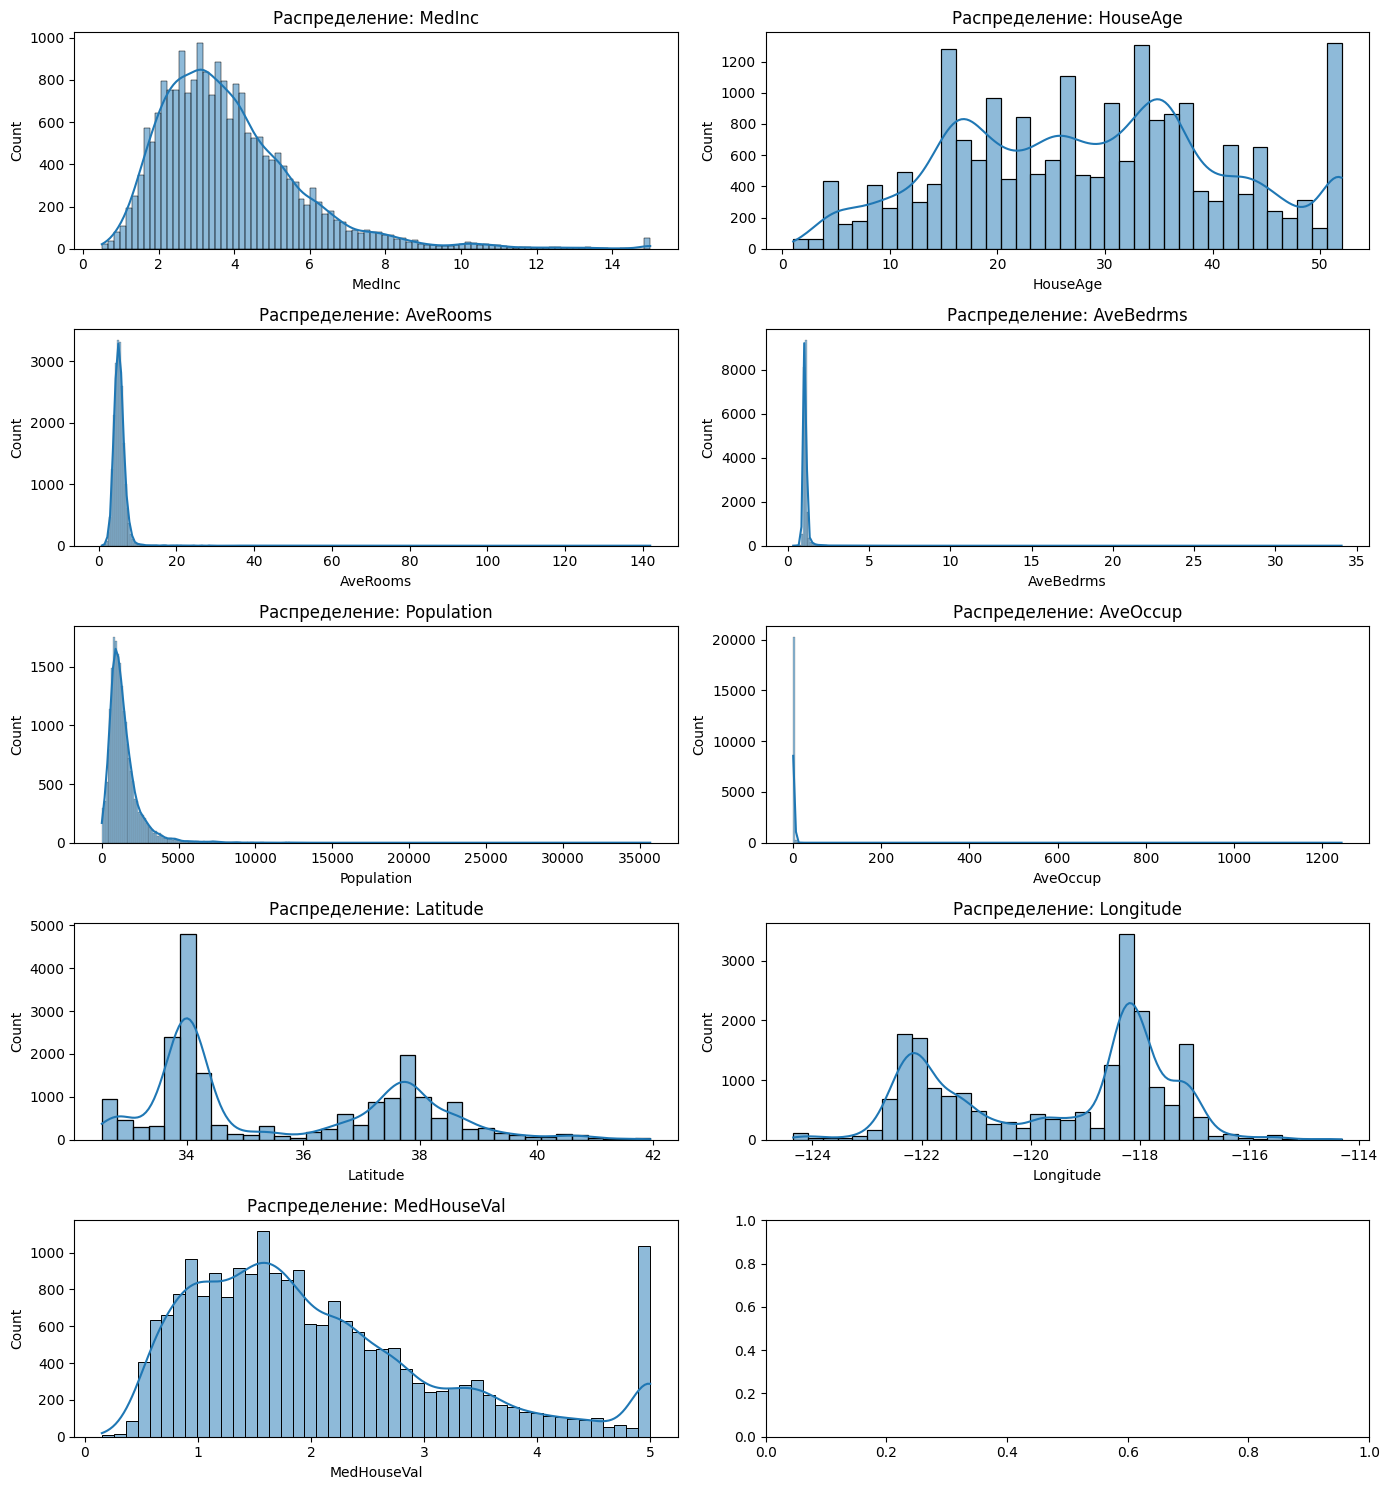

In [26]:
# Распределения
fig, axes = plt.subplots(n_rows, 2, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение: {col}')

plt.tight_layout()
plt.show()

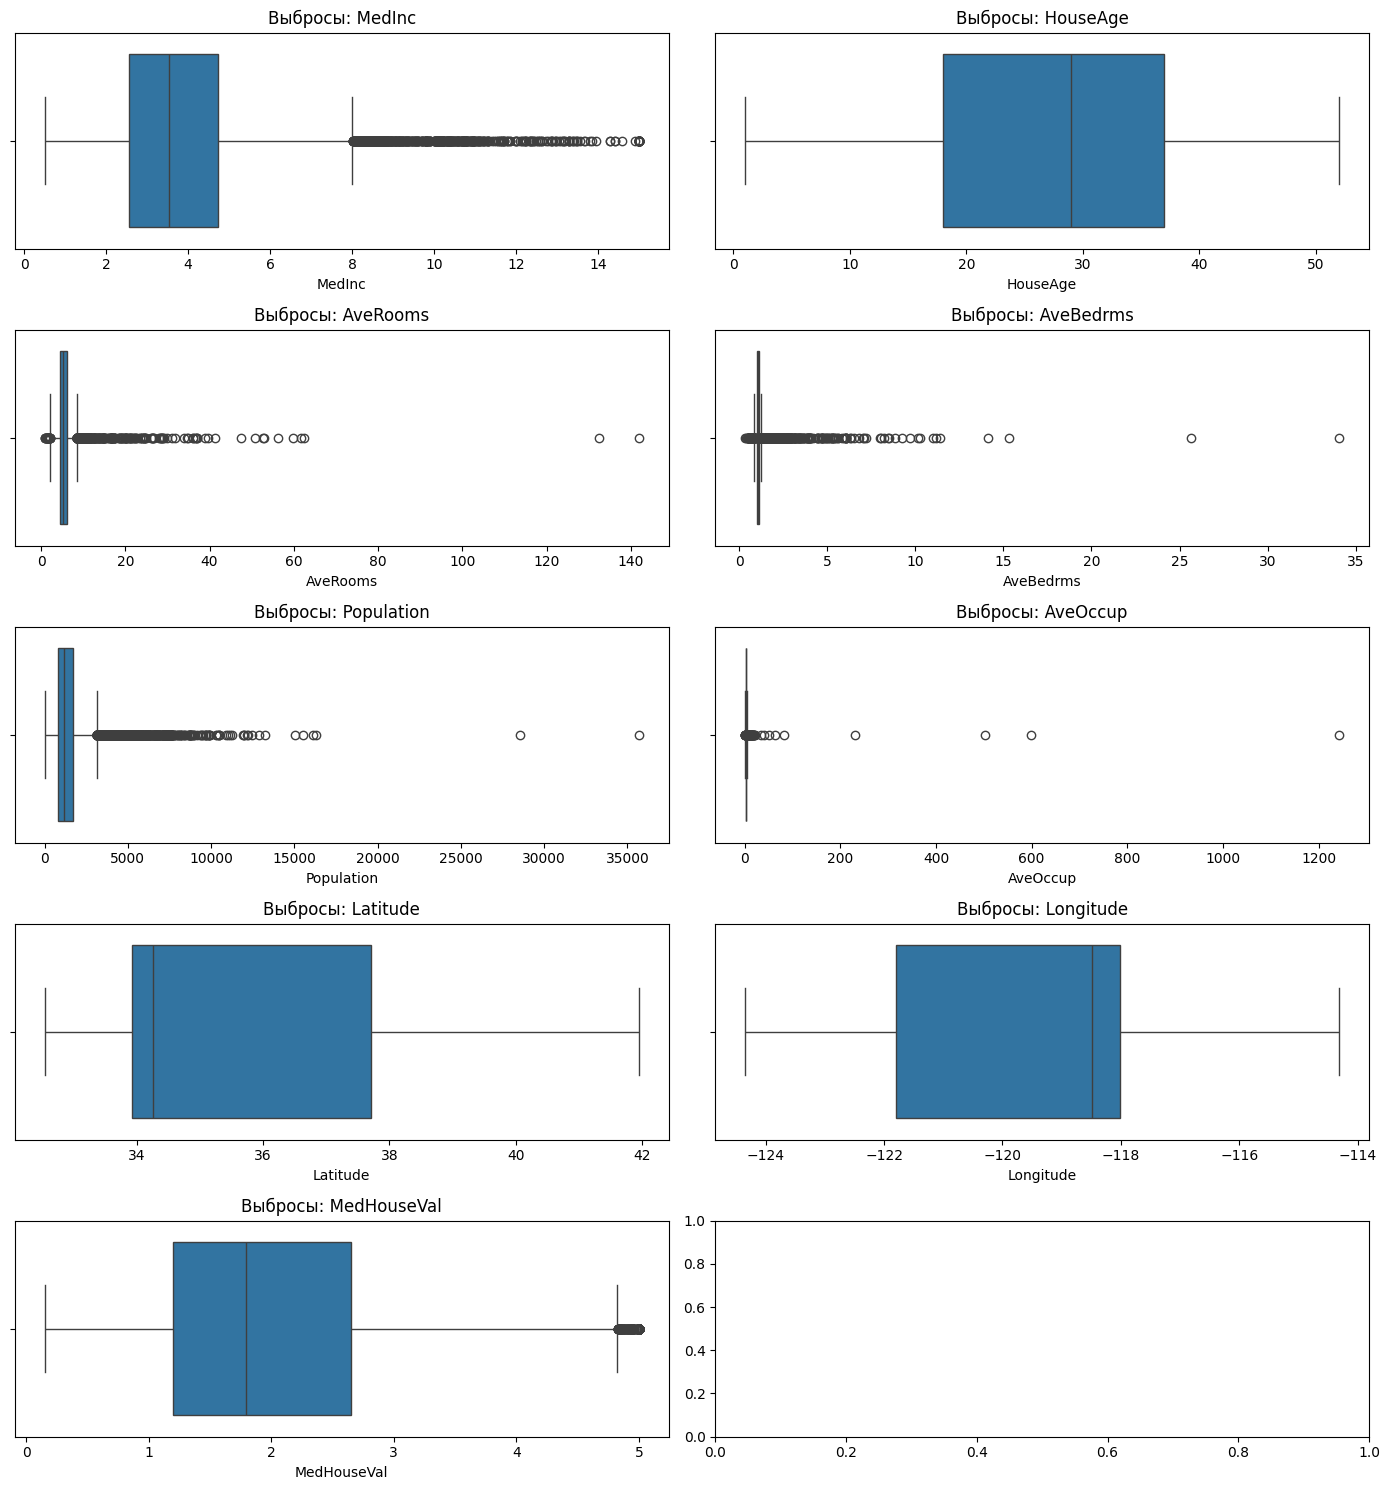

In [27]:
# Ящики с усами (выбросы)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Выбросы: {col}')

plt.tight_layout()
plt.show()

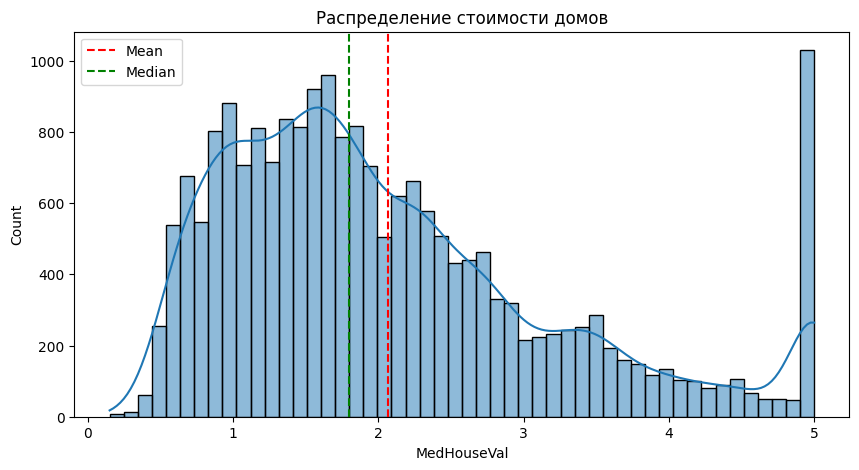

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='MedHouseVal', kde=True, bins=50)
plt.axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['MedHouseVal'].median(), color='green', linestyle='--', label='Median')
plt.title('Распределение стоимости домов')
plt.legend()
plt.show()

# Двумерный анализ

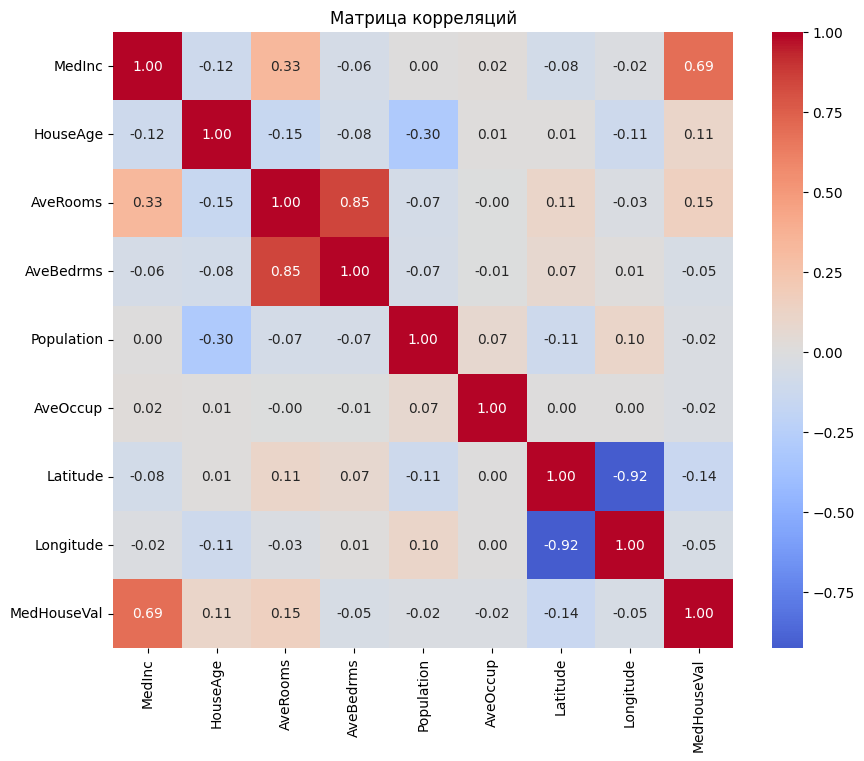

In [31]:
# Матрица корреляций
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций')
plt.show()

In [32]:
# Корреляция с target (сортированная)
corr_with_target = df.corr(numeric_only=True)['MedHouseVal'].sort_values(ascending=False)
print(corr_with_target)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


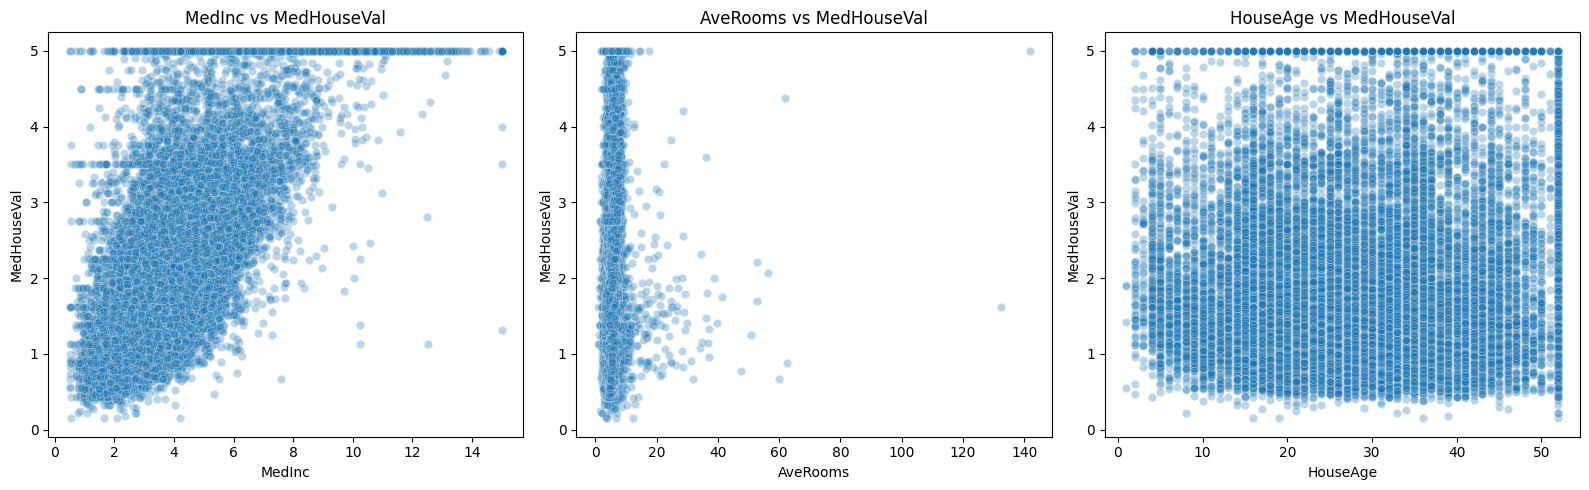

In [33]:
# Топ-3 признака по корреляции с target
top_features = ['MedInc', 'AveRooms', 'HouseAge']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(top_features):
    sns.scatterplot(data=df, x=col, y='MedHouseVal', alpha=0.3, ax=axes[i])
    axes[i].set_title(f'{col} vs MedHouseVal')

plt.tight_layout()
plt.show()

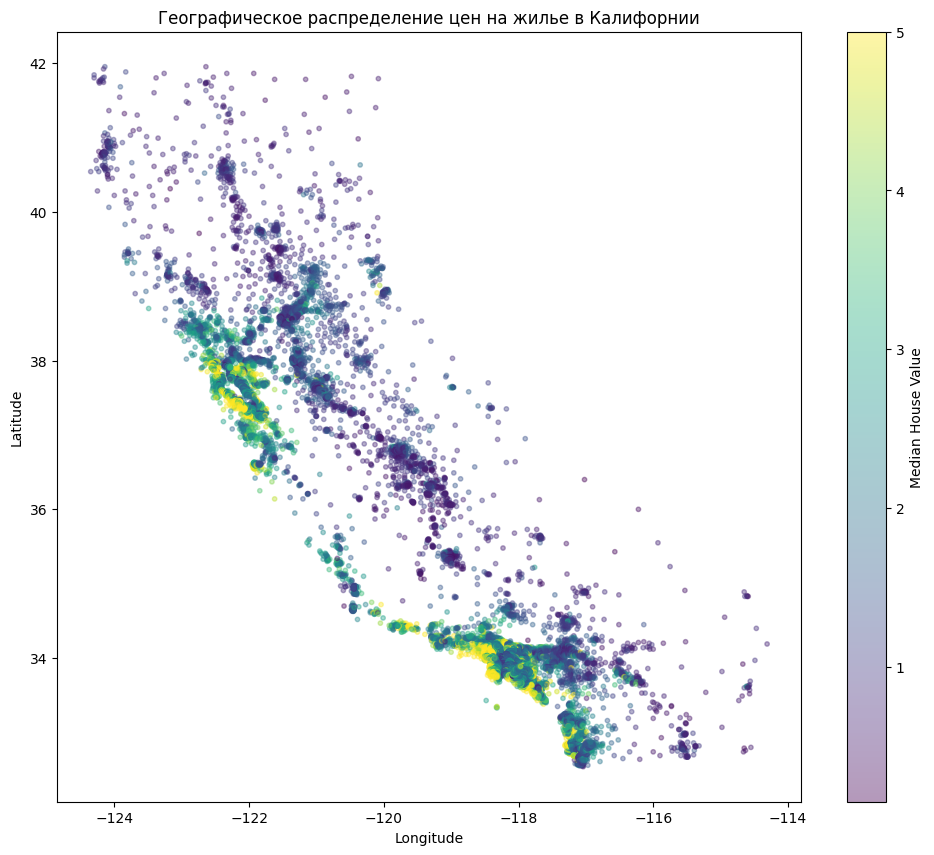

In [35]:
# Карта цен по координатам
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    df['Longitude'], 
    df['Latitude'], 
    c=df['MedHouseVal'], 
    cmap='viridis', 
    alpha=0.4,
    s=10
)
plt.colorbar(scatter, label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Географическое распределение цен на жилье в Калифорнии')
plt.show()